https://www.nature.com/articles/s41586-021-03569-1

In [38]:
%load_ext autoreload
%autoreload 2

import sys, os

# Add parent directory to Python path
sys.path.append(os.path.abspath(".."))  

In [7]:
from scrna_pipeline.utils import per_sample_export

In [3]:


report = per_sample_export.export_per_sample_h5ads(
    "/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/GSE171524_RAW_merged.h5ad",
    "/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw",
    sample_key="sample",      # <-- your obs column

    filename_suffix="raw",
)
print(report.n_cells_per_sample)


sample_id
GSM5226574_C51ctr         6099
GSM5226575_C52ctr         4513
GSM5226576_C53ctr         7120
GSM5226577_C54ctr         4382
GSM5226578_C55ctr         5685
GSM5226579_C56ctr         4090
GSM5226580_C57ctr         4789
GSM5226581_L01cov         3060
GSM5226582_L03cov         5060
GSM5226583_L04cov         3630
GSM5226584_L04covaddon    4574
GSM5226585_L05cov         3052
GSM5226586_L06cov         7582
GSM5226587_L07cov         5074
GSM5226588_L08cov         4149
GSM5226589_L09cov         3605
GSM5226590_L10cov         1550
GSM5226591_L11cov         3296
GSM5226592_L12cov         3876
GSM5226593_L13cov         4862
GSM5226594_L15cov         4056
GSM5226595_L16cov         1822
GSM5226596_L17cov         4651
GSM5226597_L18cov         2816
GSM5226598_L19cov         2509
GSM5226599_L21cov         3425
GSM5226600_L22cov         6987
Name: count, dtype: int64


In [40]:
BROAD_MARKERS = {
    "Epithelial": ["EPCAM", "KRT8", "KRT18", "KRT19"],
    "T_cell": ["CD3D", "CD3E", "CD2", "CD8A", "CD4"],
    "B_cell": ["MS4A1", "CD79A", "CD79B"],
    "Myeloid": ["LYZ", "CD68", "CD14", "TYROBP", "LST1", "CSF1R", "FCGR3A"],
    "Endothelial": ["PECAM1", "VWF", "KDR"],
    "Fibroblast": ["COL1A1", "COL1A2", "DCN"],
    "Mast": ["TPSAB1", "TPSB2", "CPA3"],
}

In [ ]:
import scanpy as sc

from scrna_pipeline.core.pipeline import StepContext, run_steps
from scrna_pipeline.pipelines.standard_per_sample import standard_per_sample_pipeline

# 1) Load one raw per-sample h5ad
adata = sc.read_h5ad("/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226595_L16cov.raw.h5ad")



# 2) Build the step list (strict workflow)
steps = standard_per_sample_pipeline(
    batch_key="batch",          # must exist in adata.obs
    marker_dict=BROAD_MARKERS,  # your dict[str, list[str]]
    # optional: override defaults if you want
    # n_top_genes=2000, n_pcs=50, n_neighbors=15, resolution=0.6, ...
)

# 3) Execute steps
ctx = StepContext(verbose=True, strict=True)
adata = run_steps(adata, steps, ctx=ctx)

adata


[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226595_L16cov kept 1374/1822 | max_genes=3032, max_counts=6627, max_mito=7.37
[QC filter] removed 448 cells; remaining 1374
Running Scrublet for doublet detection...
Removed 4 predicted doublets
After doublet removal: (1370, 19457)
[steps] 01/03 preprocess_to_pca: done (0.75s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (1.11s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.08s)


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


AnnData object with n_obs × n_vars = 1370 × 19457
    obs: 'sample', 'file', 'batch', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'broad_Epithelial_score', 'broad_T_cell_score', 'broad_B_cell_score', 'broad_Myeloid_score', 'broad_Endothelial_score', 'broad_Fibroblast_score', 'broad_Mast_score', 'broad_celltype'
    var: 'n_cells', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'scrna_pipeline', 'scrublet', 'log1p', 'hvg', 'pc

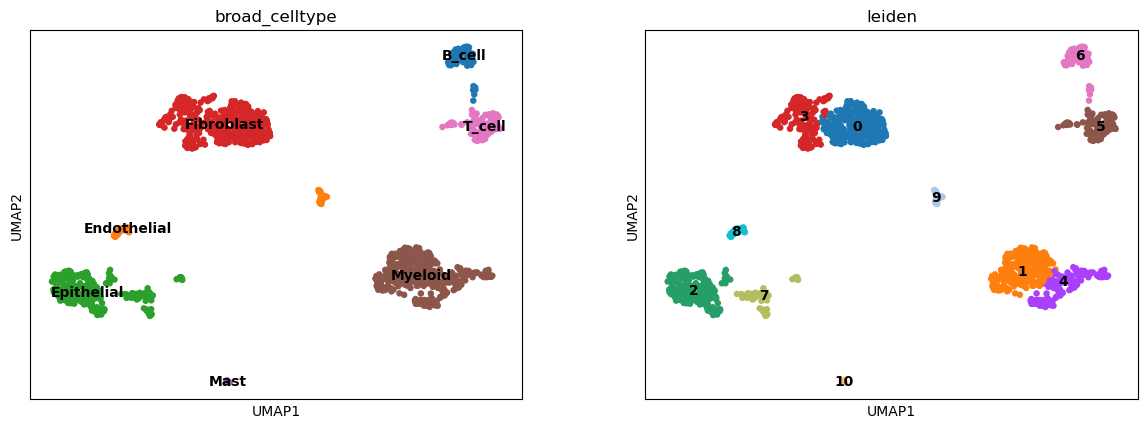

In [14]:
sc.pl.umap(adata, color=["broad_celltype", "leiden"], legend_loc="on data")


# Full Batch

In [43]:
from anndata import AnnData

def show_umap_summary(name: str, adata: AnnData) -> None:
    print(f"\n### Sample: {name}")
    sc.pl.umap(
        adata,
        color=["broad_celltype", "leiden"],
        legend_loc="on data",
        show=True,
    )

In [ ]:
from pathlib import Path

from scrna_pipeline.core.batch_runner import (
    BatchRunConfig,
    run_pipeline_on_batch,
    run_pipeline_on_h5ad_folder,
    constant_kwargs_factory,
)
from scrna_pipeline.pipelines.standard_per_sample import standard_per_sample_pipeline

# 1) Config for saving/execution
cfg = BatchRunConfig(
    out_dir=Path("/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed"),
    strip_graph=True,      # remove neighbors graph before saving
    keep_umap=True,        # keep X_umap
    keep_pca=True,         # keep X_pca
    compression="gzip",
    verbose=True,
    strict=True,
)

# 2) Same pipeline kwargs for every sample
kwargs_factory = constant_kwargs_factory({
    "batch_key": "batch",           # must exist in each adata.obs
    "marker_dict": BROAD_MARKERS,   # dict[str, list[str]]
})

# 3) Run for all samples and save <name>.processed.h5ad
saved = run_pipeline_on_batch(
    adatas_dict,  # {"sample1": adata1, "sample2": adata2, ...}
    pipeline=standard_per_sample_pipeline,
    kwargs_factory=kwargs_factory,
    config=cfg,
    on_sample_done=show_umap_summary,

)

# saved is a dict: {sample_name: Path_to_saved_h5ad}
saved


NameError: name 'adatas_dict' is not defined

In [46]:
cfg = BatchRunConfig(
    out_dir=Path("/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed"),
    strip_graph=True,      # remove neighbors graph before saving
    keep_umap=True,        # keep X_umap
    keep_pca=True,         # keep X_pca
    compression="gzip",
    verbose=True,
    strict=True,
)

saved = run_pipeline_on_h5ad_folder(
    "/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw",
    pipeline=standard_per_sample_pipeline,
    kwargs_factory=kwargs_factory,
    config=cfg,
    delete_inputs=False,   # deletes raw only after successful save
   # on_sample_done=show_umap_summary,  # or None
)


=== [GSM5226574_C51ctr.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226574_C51ctr.raw.h5ad ===

=== [GSM5226574_C51ctr.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226574_C51ctr kept 5102/6099 | max_genes=3266, max_counts=7394, max_mito=3.27
[QC filter] removed 997 cells; remaining 5102
Running Scrublet for doublet detection...
Removed 8 predicted doublets
After doublet removal: (5094, 24660)
[steps] 01/03 preprocess_to_pca: done (10.49s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (5.23s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.19s)


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


=== [GSM5226574_C51ctr.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226574_C51ctr.raw.processed.h5ad (49.9 MB) ===

=== [GSM5226575_C52ctr.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226575_C52ctr.raw.h5ad ===

=== [GSM5226575_C52ctr.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226575_C52ctr kept 3770/4513 | max_genes=3404, max_counts=9184, max_mito=7.07
[QC filter] removed 743 cells; remaining 3770
Running Scrublet for doublet detection...
Removed 26 predicted doublets
After doublet removal: (3744, 22861)
[steps] 01/03 preprocess_to_pca: done (7.39s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (3.34s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.16s)


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


=== [GSM5226575_C52ctr.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226575_C52ctr.raw.processed.h5ad (38.7 MB) ===

=== [GSM5226576_C53ctr.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226576_C53ctr.raw.h5ad ===

=== [GSM5226576_C53ctr.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226576_C53ctr kept 5734/7120 | max_genes=3566, max_counts=8631, max_mito=5.32
[QC filter] removed 1386 cells; remaining 5734
Running Scrublet for doublet detection...
Removed 70 predicted doublets
After doublet removal: (5664, 25509)
[steps] 01/03 preprocess_to_pca: done (11.81s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (5.83s)
[steps] 03/03 broad_annotation: start


...

=== [GSM5226598_L19cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226598_L19cov.raw.processed.h5ad (22.1 MB) ===

=== [GSM5226599_L21cov.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226599_L21cov.raw.h5ad ===

=== [GSM5226599_L21cov.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226599_L21cov kept 2582/3425 | max_genes=2655, max_counts=5515, max_mito=7.57
[QC filter] removed 843 cells; remaining 2582
Running Scrublet for doublet detection...
Removed 6 predicted doublets
After doublet removal: (2576, 19918)
[steps] 01/03 preprocess_to_pca: done (1.28s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (2.23s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.10s)


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


=== [GSM5226599_L21cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226599_L21cov.raw.processed.h5ad (21.1 MB) ===

=== [GSM5226600_L22cov.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226600_L22cov.raw.h5ad ===

=== [GSM5226600_L22cov.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226600_L22cov kept 5502/6987 | max_genes=2870, max_counts=6118, max_mito=3.87
[QC filter] removed 1485 cells; remaining 5502
Running Scrublet for doublet detection...
Removed 13 predicted doublets
After doublet removal: (5489, 23170)
[steps] 01/03 preprocess_to_pca: done (10.10s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (5.43s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.18s)


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


=== [GSM5226600_L22cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226600_L22cov.raw.processed.h5ad (47.8 MB) ===


# Integration


=== GSM5226586_L06cov.raw.processed.h5ad ===
shape: (5783, 23592)
obs keys: ['sample', 'file', 'batch', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'] ...
var keys: ['n_cells', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'] 
layers: ['counts', 'log1p']
obsm: ['X_pca', 'X_umap']
uns has pca: True
has X_pca: True
has umap: True
has neighbors: False
raw: True raw shape: (5783, 23592)


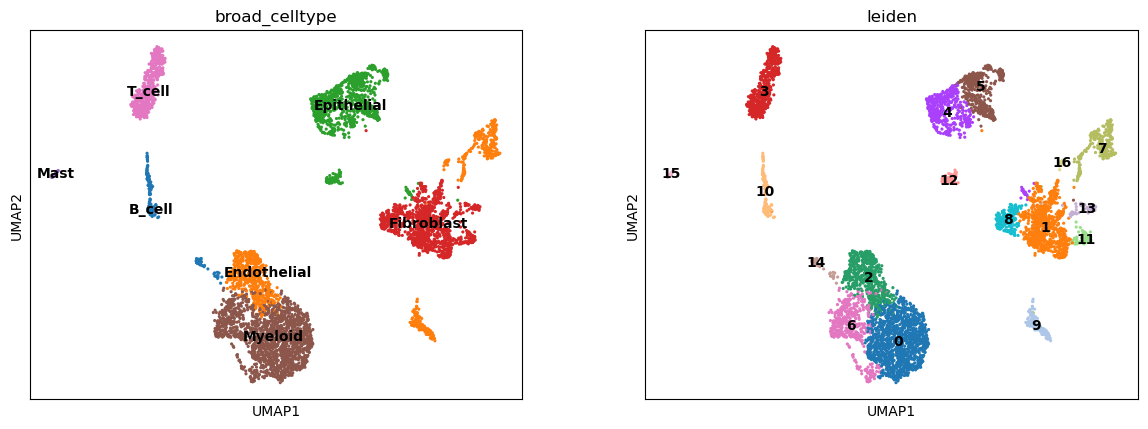


=== GSM5226595_L16cov.raw.processed.h5ad ===
shape: (1370, 19457)
obs keys: ['sample', 'file', 'batch', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'] ...
var keys: ['n_cells', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'] 
layers: ['counts', 'log1p']
obsm: ['X_pca', 'X_umap']
uns has pca: True
has X_pca: True
has umap: True
has neighbors: False
raw: True raw shape: (1370, 19457)


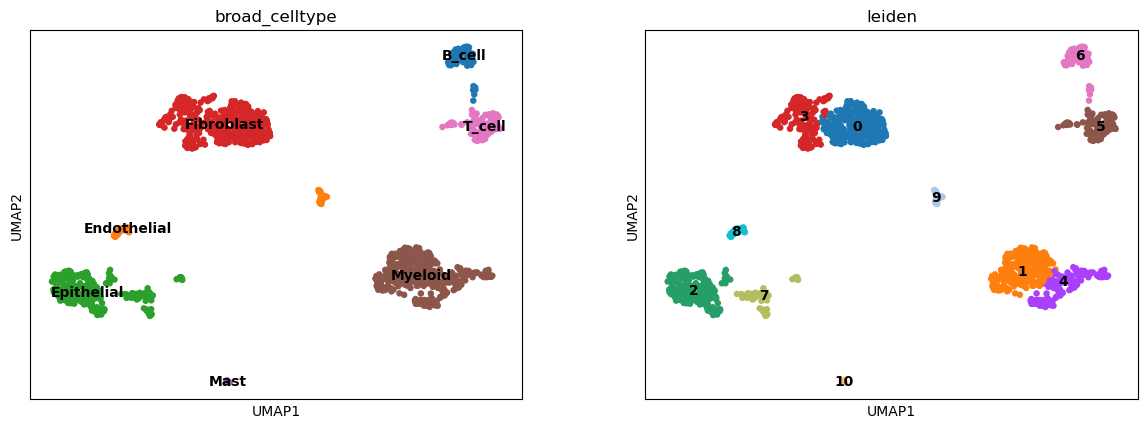

In [47]:
import scanpy as sc
from pathlib import Path

paths = [
    Path("/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_some_processed/GSM5226586_L06cov.raw.processed.h5ad"),
    Path("/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_some_processed/GSM5226595_L16cov.raw.processed.h5ad"),
    
]

for p in paths:
    ad = sc.read_h5ad(p)
    print("\n===", p.name, "===")
    print("shape:", ad.shape)
    print("obs keys:", list(ad.obs.columns)[:15], "..." if ad.obs.shape[1] > 15 else "")
    print("var keys:", list(ad.var.columns)[:15], "..." if ad.var.shape[1] > 15 else "")
    print("layers:", list(ad.layers.keys()))
    print("obsm:", list(ad.obsm.keys()))
    print("uns has pca:", "pca" in ad.uns)
    print("has X_pca:", "X_pca" in ad.obsm)
    print("has umap:", "X_umap" in ad.obsm)
    print("has neighbors:", "neighbors" in ad.uns)
    print("raw:", ad.raw is not None, ("raw shape: " + str(ad.raw.shape) if ad.raw is not None else ""))
    sc.pl.umap(
        ad,
        color=["broad_celltype", "leiden"],
        legend_loc="on data",
        show=True,
    )
    


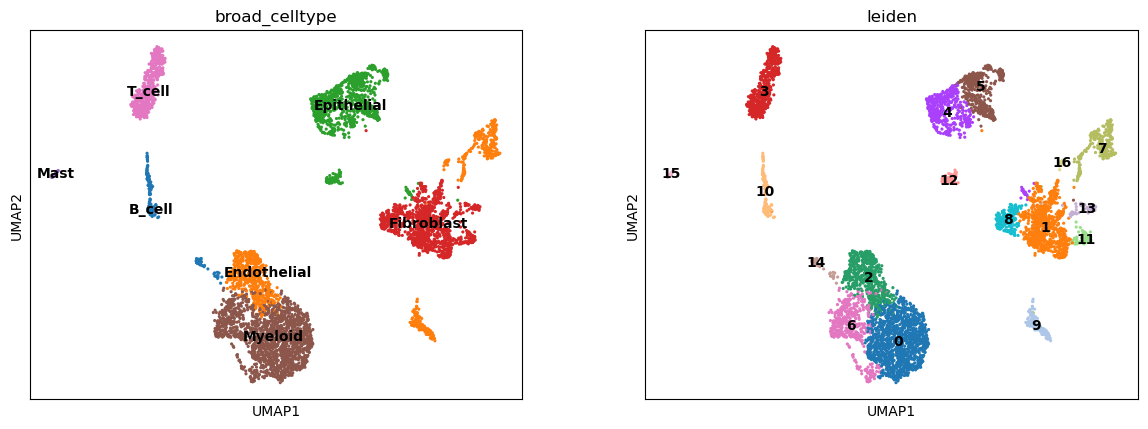

In [48]:
adata = sc.read_h5ad("/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_some_processed/GSM5226586_L06cov.raw.processed.h5ad")

sc.pl.umap(
        adata,
        color=["broad_celltype", "leiden"],
        legend_loc="on data",
        show=True,
    )

In [49]:
adata_deleted,report = strip_per_sample_artifacts(adata)

print(adata_deleted)

adata_deleted   



AnnData object with n_obs × n_vars = 5783 × 23592
    obs: 'sample', 'file', 'batch', 'sample_id', 'broad_Epithelial_score', 'broad_T_cell_score', 'broad_B_cell_score', 'broad_Myeloid_score', 'broad_Endothelial_score', 'broad_Fibroblast_score', 'broad_Mast_score', 'broad_celltype'
    layers: 'counts', 'log1p'


AnnData object with n_obs × n_vars = 5783 × 23592
    obs: 'sample', 'file', 'batch', 'sample_id', 'broad_Epithelial_score', 'broad_T_cell_score', 'broad_B_cell_score', 'broad_Myeloid_score', 'broad_Endothelial_score', 'broad_Fibroblast_score', 'broad_Mast_score', 'broad_celltype'
    layers: 'counts', 'log1p'

In [51]:
from scrna_pipeline.utils.concat_samples import combine_samples, CombineConfig

combined, reports = combine_samples(
    folder="/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed",
    cfg=CombineConfig(sample_key="sample_id"),
)


In [52]:
print(combined)

AnnData object with n_obs × n_vars = 92587 × 29602
    obs: 'sample', 'file', 'batch', 'sample_id', 'broad_Epithelial_score', 'broad_T_cell_score', 'broad_B_cell_score', 'broad_Myeloid_score', 'broad_Endothelial_score', 'broad_Fibroblast_score', 'broad_Mast_score', 'broad_celltype'
    layers: 'counts', 'log1p'


In [53]:
combined.obs_names.is_unique

True

In [54]:
for k in combined.layers:
    assert combined.layers[k].shape == combined.shape


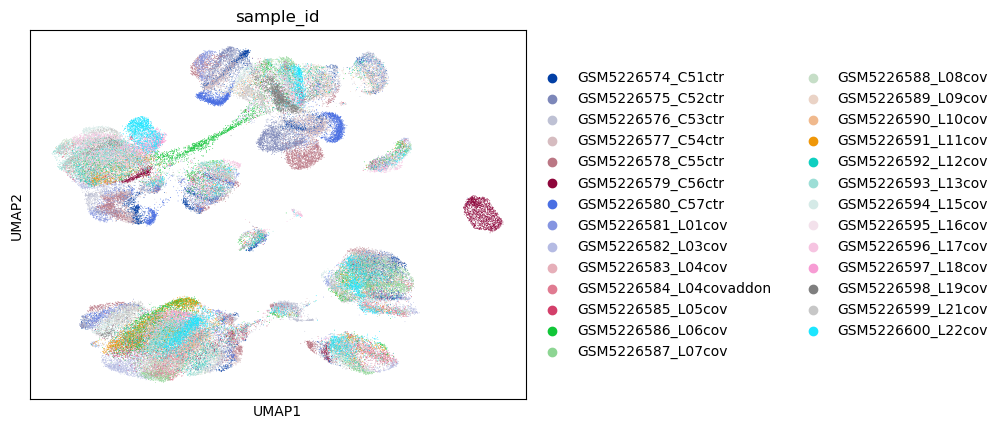

In [55]:
sc.pp.pca(combined)
sc.pp.neighbors(combined)
sc.tl.umap(combined)

sc.pl.umap(combined, color='sample_id')


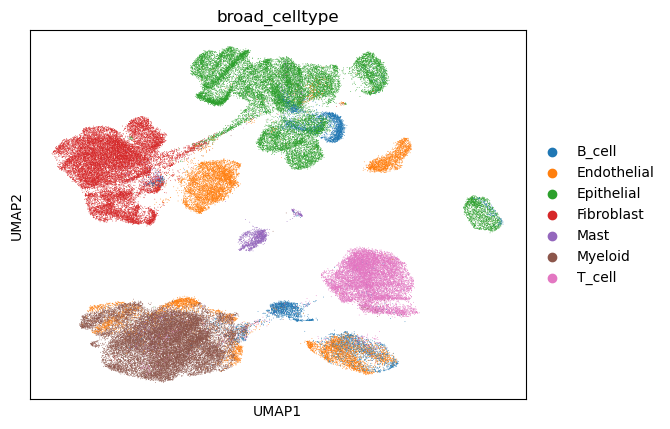

In [56]:
sc.pl.umap(combined, color='broad_celltype')